In [48]:
## Import Modules
from phi.flow import *
import matplotlib.pyplot as plt

In [49]:
v=StaggeredGrid(
    values= lambda pos: vec(
        x=math.cos(pos).vector["x"]*math.sin(pos).vector["y"],
        y=math.sin(pos).vector['x']*math.cos(pos).vector['y'],
    ),
    extrapolation=extrapolation.PERIODIC,
    x=25,
    y=25,
    bounds=Box(x=2*PI , y=2*PI)
)

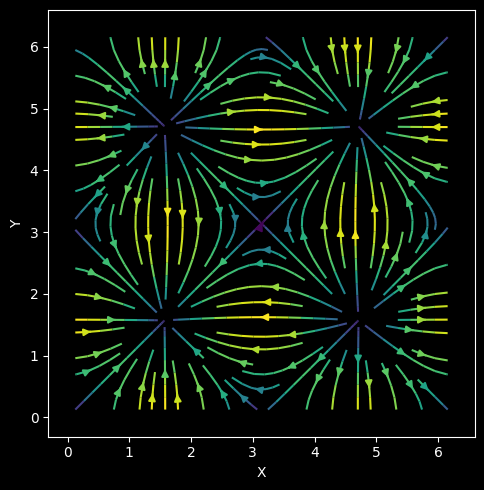

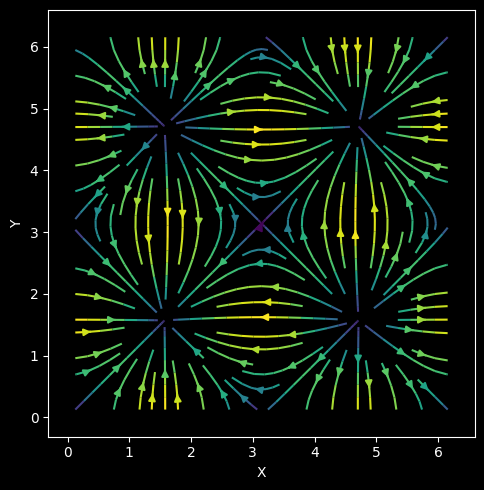

In [50]:
plt.style.use("dark_background")
plot(v)

In [51]:
def make_step(v,dt=0.5):
    v=advect.semi_lagrangian(v,v,dt=dt)
    v=diffuse.implicit(v,0.1,dt)
    v,_=fluid.make_incompressible(v)
    return v

In [52]:
import matplotlib.animation as animation
writer=animation.PillowWriter(fps=(10))
trj=iterate(make_step,batch(time=20),v)
plot(trj,animate="time",size=(5,5))

C:\Users\622009\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\phiml\backend\_linalg.py:346: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  x = spsolve(matrix, y[batch])  # returns nan when diverges


RuntimeError: Requested MovieWriter (ffmpeg) not available